# Laboratorio 2

## Integrantes

- Sergio Orellana 221122
- Ricardo Chuy 221007
- Rodrigo Mansilla 22611

## Task 4

### Con base en los resultados de la implementación, produzcan un dictamen técnico que incluya:

#### 1. Verificación de consistencia: comprueben que las políticas óptimas producidas por Policy Iteration y Value Iteration son idénticas. Si difieren en algún estado, expliquen por qué puede ocurrir eso y cómo resolverlo. Si son idénticas, interpreten en lenguaje operacional qué le está diciendo la política óptima al sistema de control del ascensor.

_Respuesta:_

Las políticas coinciden en los 10 estados, y la diferencia  entre sus tablas de valores es de , un orden de magnitud consistente con el umbral  que usamos como criterio de paro. Es decir, la pequeña diferencia numérica no refleja un desacuerdo real entre los algoritmos, sino el margen de error que aceptamos al truncar la convergencia en un número finito de barridos.

Vale la pena notar que en los estados (2,1), (3,1) y (4,1) las acciones subir y bajar producen exactamente el mismo valor $q$, porque ambas mueven al ascensor a un piso distinto y por lo tanto atienden la demanda con la misma recompensa inmediata , y porque todo estado sin demanda tiene el mismo sin importar el piso .     Estos 3 Estados empatan entre subir y bajar, y los dos algoritmos lo resolvieron de la misma forma porque ambos usan `np.argmax` sobre la misma lista `ACCIONES=[SUBIR, BAJAR, PERMANECER]`, que siempre devuelve la primera acción que alcanza el máximo. Esto no significa que alguno de los dos algoritmos está mal, sino de una regla de desempate distinta que se resolvería verificando que los valores $q$ en disputa son iguales antes de comparar qué acción reportó cada uno.



#### 2. Análisis de convergencia: comparen el número de iteraciones y el tiempo de ejecución de ambos algoritmos. ¿El resultado coincide con la predicción teórica que hicieron en la Tarea 2? Si no coincide, identifiquen la fuente de la discrepancia.

_Respuesta:_

Policy Iteration convergió en solo 2 ciclos externos y tardó 0.025862 s, mientras que Value Iteration requirió 271 barridos y tardó 0.079523 s. Aunque ambos hicieron un número similar de barridos sobre los estados, Policy Iteration fue aproximadamente 3 veces más rápido.

La diferencia no está en la cantidad de barridos, sino en el costo de cada un en donde Policy Iteration calcula un solo valor \(q\) por estado en cada barrido, mientras que Value Iteration calcula los tres valores \(q\) para luego tomar el máximo.ando que el tiempo está dominado por el costo por barrido.

Este resultado no contradice lo previsto en la Tarea 2, sino que confirma la excepción  mencionada,  para un MDP muy pequeño, como el de la Task 3 con 10 estados y 3 acciones, Policy Iteration puede ser más rápido porque converge en muy pocos ciclos externos. En cambio, para un MDP grande y disperso, Value Iteration seguiría siendo más conveniente por su menor costo por barrido.



#### 3. Análisis de sensibilidad a $\gamma$: repitan ambos algoritmos con $\gamma \in \{0.5, 0.75, 0.99\}$. Grafiquen el valor $V^*(s_0)$ del estado inicial en función de $\gamma$ para ambos algoritmos. ¿Cómo cambia la política óptima? ¿En qué valor de $\gamma$ cambia cualitativamente el comportamiento del ascensor?

Reconstruimos el MDP de la Task 3 en este notebook (cada task vive en su propio `.ipynb`) y reejecutamos Policy Iteration y Value Iteration variando $\gamma$. Incluimos $\gamma=0.95$ como referencia directa contra los resultados ya obtenidos en la Task 3.

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt

THETA = 1e-6      
GAMMA_BASE = 0.95   

R_PASO = -1.0              
R_ATENDER = 10.0           
R_MOVIMIENTO = -0.5       

PISOS = [1, 2, 3, 4, 5]
DEMANDA = [0, 1]
ESTADOS = [(p, d) for p in PISOS for d in DEMANDA]
INDICE = {estado: i for i, estado in enumerate(ESTADOS)}

SUBIR, BAJAR, PERMANECER = 0, 1, 2
ACCIONES = [SUBIR, BAJAR, PERMANECER]
NOMBRE_ACCION = {SUBIR: "subir", BAJAR: "bajar", PERMANECER: "permanecer"}

n_estados = len(ESTADOS)
n_acciones = len(ACCIONES)

s0 = INDICE[(1, 0)]  # estado inicial

print("Cantidad de estados:", n_estados, " Cantidad de acciones:", n_acciones)
print("Estado inicial s0 =", ESTADOS[s0])

Cantidad de estados: 10  Cantidad de acciones: 3
Estado inicial s0 = (1, 0)


In [ ]:
def paso(estado, accion):
    """Dinámica determinista del ascensor (idéntica a la Task 3).

    Devuelve el estado siguiente s' y la recompensa r(s, a, s'). Al ser
    determinista, define por completo p(s' | s, a): vale 1 para el sucesor
    que devuelve y 0 para todos los demás estados.
    """
    piso, demanda = estado

    if accion == SUBIR:
        piso_siguiente = min(piso + 1, 5)
    elif accion == BAJAR:
        piso_siguiente = max(piso - 1, 1)
    else:
        piso_siguiente = piso

    hubo_cambio_de_piso = piso_siguiente != piso

    if demanda == 1 and hubo_cambio_de_piso:
        return (piso_siguiente, 0), R_ATENDER
    if demanda == 1:
        return (piso, 1), R_PASO

    recompensa = R_PASO
    if accion != PERMANECER:
        recompensa += R_MOVIMIENTO
    return (piso_siguiente, 0), recompensa


P = np.zeros((n_estados, n_acciones, n_estados))
R = np.zeros((n_estados, n_acciones, n_estados))

for s, estado in enumerate(ESTADOS):
    for a in ACCIONES:
        siguiente, recompensa = paso(estado, a)
        s_siguiente = INDICE[siguiente]
        P[s, a, s_siguiente] = 1.0
        R[s, a, s_siguiente] = recompensa

print("Todas las distribuciones p(. | s, a) suman 1:", np.allclose(P.sum(axis=2), 1.0))

Todas las distribuciones p(. | s, a) suman 1: True


In [3]:
def valor_q(s, a, V, gamma):
    """q(s, a) = suma_{s'} p(s' | s, a) [ r(s, a, s') + gamma * V(s') ]."""
    return float(np.sum(P[s, a] * (R[s, a] + gamma * V)))


def politica_greedy(V, gamma):
    """Política voraz respecto de V: pi(s) = argmax_a q(s, a)."""
    return np.array(
        [int(np.argmax([valor_q(s, a, V, gamma) for a in ACCIONES])) for s in range(n_estados)]
    )


def policy_evaluation(politica, gamma, theta=THETA, V_inicial=None):
    """Policy Evaluation (idéntica a la Task 3), reutilizada por Policy Iteration.

    Aplica V(s) <- q(s, pi(s)) hasta que el cambio máximo entre barridos
    queda por debajo de theta. Aquí gamma es siempre un parámetro explícito
    porque el análisis de sensibilidad necesita variarlo.
    """
    V = np.zeros(n_estados) if V_inicial is None else V_inicial.copy()
    barridos = 0
    aplicaciones = 0

    while True:
        delta = 0.0
        for s in range(n_estados):
            v_anterior = V[s]
            V[s] = valor_q(s, politica[s], V, gamma)
            aplicaciones += 1
            delta = max(delta, abs(v_anterior - V[s]))
        barridos += 1
        if delta < theta:
            break

    return V, barridos, aplicaciones


def policy_iteration(gamma, theta=THETA):
    """Policy Iteration completo (idéntico a la Task 3), parametrizado en gamma."""
    inicio = time.perf_counter()
    politica = np.full(n_estados, PERMANECER, dtype=int)
    V = np.zeros(n_estados)

    iteraciones_externas = 0
    barridos_totales = 0
    aplicaciones_bellman = 0

    while True:
        V, barridos, aplicaciones = policy_evaluation(politica, gamma, theta, V)
        barridos_totales += barridos
        aplicaciones_bellman += aplicaciones

        politica_estable = True
        for s in range(n_estados):
            accion_anterior = politica[s]
            politica[s] = int(np.argmax([valor_q(s, a, V, gamma) for a in ACCIONES]))
            aplicaciones_bellman += 1
            if politica[s] != accion_anterior:
                politica_estable = False

        iteraciones_externas += 1
        if politica_estable:
            break

    tiempo = time.perf_counter() - inicio
    return {
        "nombre": "Policy Iteration",
        "gamma": gamma,
        "V": V,
        "politica": politica,
        "iteraciones": iteraciones_externas,
        "barridos": barridos_totales,
        "aplicaciones_bellman": aplicaciones_bellman,
        "tiempo": tiempo,
    }


def value_iteration(gamma, theta=THETA):
    """Value Iteration (idéntico a la Task 3), parametrizado en gamma."""
    inicio = time.perf_counter()
    V = np.zeros(n_estados)

    iteraciones = 0
    aplicaciones_bellman = 0

    while True:
        delta = 0.0
        for s in range(n_estados):
            v_anterior = V[s]
            V[s] = max(valor_q(s, a, V, gamma) for a in ACCIONES)
            aplicaciones_bellman += 1
            delta = max(delta, abs(v_anterior - V[s]))
        iteraciones += 1
        if delta < theta:
            break

    politica = politica_greedy(V, gamma)
    tiempo = time.perf_counter() - inicio
    return {
        "nombre": "Value Iteration",
        "gamma": gamma,
        "V": V,
        "politica": politica,
        "iteraciones": iteraciones,
        "barridos": iteraciones,
        "aplicaciones_bellman": aplicaciones_bellman,
        "tiempo": tiempo,
    }

In [ ]:
GAMMAS = sorted({0.5, 0.75, 0.99, GAMMA_BASE})

resultados = []
for g in GAMMAS:
    r_pi = policy_iteration(g)
    r_vi = value_iteration(g)
    resultados.append((g, r_pi, r_vi))

print(f"{'gamma':>6}{'V_PI*(s0)':>14}{'politica PI':>16}{'V_VI*(s0)':>14}{'politica VI':>16}")
for g, r_pi, r_vi in resultados:
    print(
        f"{g:>6.2f}"
        f"{r_pi['V'][s0]:>14.4f}"
        f"{NOMBRE_ACCION[r_pi['politica'][s0]]:>16}"
        f"{r_vi['V'][s0]:>14.4f}"
        f"{NOMBRE_ACCION[r_vi['politica'][s0]]:>16}"
    )

print()
print("Política completa por gamma (Value Iteration; Policy Iteration coincide en todos los casos):")
for g, _, r_vi in resultados:
    politica_str = ", ".join(
        f"({p},{d})->{NOMBRE_ACCION[a]}" for (p, d), a in zip(ESTADOS, r_vi["politica"])
    )
    print(f"gamma={g:.2f}: {politica_str}")

 gamma     V_PI*(s0)     politica PI     V_VI*(s0)     politica VI
  0.50       -2.0000      permanecer       -2.0000      permanecer
  0.75       -4.0000      permanecer       -4.0000      permanecer
  0.95      -20.0000      permanecer      -20.0000      permanecer
  0.99      -99.9999      permanecer      -99.9999      permanecer

Política completa por gamma (Value Iteration; Policy Iteration coincide en todos los casos):
gamma=0.50: (1,0)->permanecer, (1,1)->subir, (2,0)->permanecer, (2,1)->subir, (3,0)->permanecer, (3,1)->subir, (4,0)->permanecer, (4,1)->subir, (5,0)->permanecer, (5,1)->bajar
gamma=0.75: (1,0)->permanecer, (1,1)->subir, (2,0)->permanecer, (2,1)->subir, (3,0)->permanecer, (3,1)->subir, (4,0)->permanecer, (4,1)->subir, (5,0)->permanecer, (5,1)->bajar
gamma=0.95: (1,0)->permanecer, (1,1)->subir, (2,0)->permanecer, (2,1)->subir, (3,0)->permanecer, (3,1)->subir, (4,0)->permanecer, (4,1)->subir, (5,0)->permanecer, (5,1)->bajar
gamma=0.99: (1,0)->permanecer, (1,1)->subir

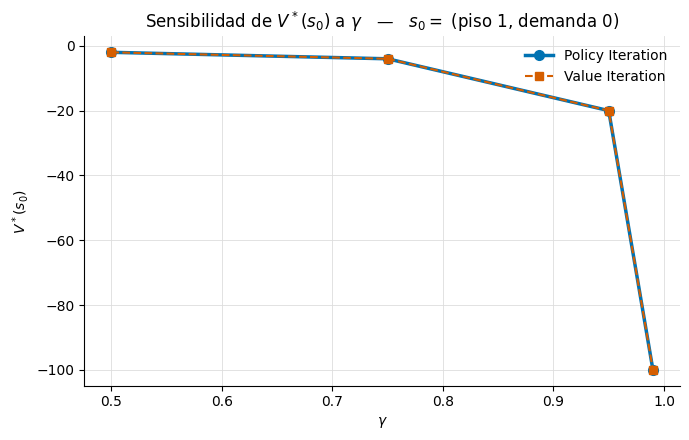

In [ ]:
# Gráfico de V*(s0) en función de gamma para los dos algoritmos. 
valores_pi = [r_pi["V"][s0] for _, r_pi, _ in resultados]
valores_vi = [r_vi["V"][s0] for _, _, r_vi in resultados]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(GAMMAS, valores_pi, marker="o", markersize=7, color="#0072B2",
        linewidth=2.5, label="Policy Iteration")
ax.plot(GAMMAS, valores_vi, marker="s", markersize=6, color="#D55E00",
        linewidth=1.5, linestyle="--", label="Value Iteration")

ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$V^*(s_0)$")
ax.set_title(r"Sensibilidad de $V^*(s_0)$ a $\gamma$   —   $s_0=$ (piso 1, demanda 0)")
ax.grid(True, color="#dddddd", linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


$V^*(s_0)$ cambia fuertemente con $\gamma$ $-2.0000,\ -4.0000,\ -20.0000,\ -99.9999,$ para $s_0 =$ “piso 1, demanda 0”. Sin embargo, la política óptima no cambia para ninguno de esos valores de $\gamma$, ni en Policy Iteration ni en Value Iteration.

Esto se debe a que el MDP simplificado no modela la llegada de nuevas demandas, desde un estado con $d=0$, ninguna acción puede llevar a un estado con $d=1$. Una vez atendida la única demanda, el ascensor queda permanentemente sin trabajo. 
Quedarse quieto produce costo $-1$ en cada paso.

La política tampoco cambia con $\gamma$ porque no existe un conflicto de largo plazo que el factor de descuento deba arbitrar. En los estados sin demanda, moverse cuesta $-1.5$, mientras que quedarse cuesta $-1$, por lo que quedarse es siempre mejor. En los estados con demanda, atender la llamada da $+1$,  mejor que quedarse esperando con $-1$. 

El comportamiento cualitativo del ascensor no cambia en ningún valor de $\gamma$ dentro del intervalo probado. 

#### 4. Conexión con el diseño propio: comparen la política óptima obtenida para el MDP simplificado con el comportamiento que esperarían del MDP que diseñaron en la Tarea 1. ¿Qué aspectos del problema real no captura el MDP simplificado? ¿Cómo afectaría eso a la política óptima en el dominio real?

_Respuesta:_

La política del MDP simplificado es un controlador reactivo básico . Aunque funciona para probar el código, es insuficiente para el entorno real de la Tarea 1 por que:

1.  **Estado:** El modelo simple usa un solo bit con/sin demanda, ignorando ubicación y urgencia. No puede gestionar múltiples llamadas simultáneas ni decidir prioridades.
2.  **Transiciones:** El modelo simplificado es determinista y se "detiene" tras la primera demanda. El MDP real es estocástico, ya que las solicitudes llegan de forma impredecible y continua.
3.  **Recompensas:** El modelo simple otorga el mismo valor (+10) a cualquier llamada. El de la Tarea 1 prioriza explícitamente las emergencias (+40) sobre las normales (+12).



#### 5. Dictamen final: redacten un párrafo dirigido a la gerencia del hospital argumentando si Programación Dinámica es una solución viable para el sistema de ascensores real, cuáles son sus limitaciones principales, y qué metodología recomendarían como paso siguiente.

_Respuesta:_
Programación Dinámica es un primer paso viable y de bajo riesgo. Con el modelo tabular, Policy Iteration y Value Iteration convergen al mismo óptimo, con una diferencia de apenas fracciones de segundo. Esto entrega una política  óptima para el ascensor simplificado, permitiendo validar el diseño de recompensas con bajo costo.

Su principal limitación es la escala. El enfoque tabular puede manejar el modelo de un solo ascensor con aproximadamente 1,000,000 de estados gracias a que las transiciones son dispersas, pero deja de ser práctico al coordinar varios ascensores, porque el espacio de estados crece combinatoriamente.

Recomendación: usar Programación Dinámica ahora para validar la función de recompensa y obtener una política de referencia óptima. Luego, para el problema completo con varios ascensores, migrar a métodos con aproximación de funciones o aprendizaje por refuerzo, usando esta solución exacta como referencia para evaluar las políticas aprendidas.


### USO DE IA

El uso de IA en la task se hizo por medio de una metodología de explicación teórica (IA) -> Abstracción de conceptos (HUMANO) -> sintesis (IA) -> Redacción (AMBOS) -> Curación (HUMANO)

Reforzando la buena práctica de Human in the LOOP